# Notebook 18 — TimTrack Parity and Segment Direction

This notebook is a trace of the next step toward a faithful Python reproduction of MATLAB UltraTimTrack.

The goal is not to tune the Kalman filter yet. The goal is to see, with graphs, where the current Python pipeline diverges from MATLAB and why the `segment_from_state()` geometry needs attention.

Main questions in this notebook:

1. How far are the final Python outputs from MATLAB `Fdat.Region.FL`, `PEN`, and `ANG`?
2. How far is the Python TimTrack-like step from MATLAB `Fdat.geofeatures`?
3. What changes geometrically if we use the proposed `segment_from_state()` branch?
4. What should the next implementation step be?


In [1]:
import sys
from pathlib import Path
import importlib

%load_ext autoreload
%autoreload 2

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import ultrasound_tracker.matlab_compat as mc
import ultrasound_tracker.legacy.ultratimtrack_kalman as utt

mc = importlib.reload(mc)
utt = importlib.reload(utt)

print("matlab_compat:", mc.__file__)
print("ultratimtrack_kalman:", utt.__file__)

matlab_compat: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/matlab_compat.py
ultratimtrack_kalman: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/ultratimtrack_kalman.py


In [3]:
MATLAB_RESULT_PATH = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
PY_TIMTRACK_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_features_arrays.npz"
PY_UTT_NPZ = PROJECT_ROOT / "results" / "ultratimtrack_geometric_kalman_features_arrays.npz"
OUT_PARITY_CSV = PROJECT_ROOT / "results" / "matlab_comparison" / "parity_metrics.csv"

for path in [MATLAB_RESULT_PATH, VIDEO_PATH, PY_TIMTRACK_NPZ, PY_UTT_NPZ]:
    print(path, "exists=", path.exists())

/Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat exists= True
/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 exists= True
/Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_features_arrays.npz exists= True
/Users/grosbedou/PycharmProjects/NDORMS/results/ultratimtrack_geometric_kalman_features_arrays.npz exists= True


In [4]:
mat = mc.load_matlab_result(MATLAB_RESULT_PATH)
mat_final = mc.extract_final_region_arrays(mat)
mat_geo = mc.extract_geofeature_arrays(mat)

py_tim = np.load(PY_TIMTRACK_NPZ, allow_pickle=True)
py_utt = np.load(PY_UTT_NPZ, allow_pickle=True)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
n_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
ret, frame0 = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read first video frame")

if frame0.ndim == 3:
    frame0_gray = cv2.cvtColor(frame0, cv2.COLOR_BGR2GRAY)
else:
    frame0_gray = frame0.copy()

image_height_px, image_width_px = frame0_gray.shape
image_depth_mm = float(mat_final["image_depth_mm"])
mm_per_pixel = image_depth_mm / image_height_px

print("Video FPS:", fps)
print("Video frames:", n_video_frames)
print("Frame shape:", frame0_gray.shape)
print("MATLAB image depth mm:", image_depth_mm)
print("Current mm_per_pixel:", mm_per_pixel)
print("MATLAB final frames:", len(mat_final["length_mm"]))
print("Python UTT frames:", len(py_utt["utt_fascicle_length_px"]))
print("Python TimTrack-like frames:", len(py_tim["fascicle_length_px"]))

Video FPS: 33.341
Video frames: 2667
Frame shape: (562, 706)
MATLAB image depth mm: 50.7
Current mm_per_pixel: 0.09021352313167261
MATLAB final frames: 2666


Python UTT frames: 2667
Python TimTrack-like frames: 2667


## 1. Final Output Parity Baseline

This reproduces the comparison target: MATLAB final outputs from `Fdat.Region` versus the current Python UltraTimTrack-like output.

Interpretation:

- `bias = Python - MATLAB`
- positive correlation is good
- negative correlation means the shape/trend is going in the wrong direction
- this is the final validation gate, but not the first thing to fix


In [5]:
final_pairs = {
    "FL_mm": (
        mat_final["length_mm"],
        py_utt["utt_fascicle_length_px"] * mm_per_pixel,
        "Fascicle length (mm)",
    ),
    "PEN_deg": (
        mat_final["pennation_deg"],
        py_utt["utt_pennation_angle_deg"],
        "Pennation angle (deg)",
    ),
    "ANG_deg": (
        mat_final["fascicle_angle_deg"],
        py_utt["utt_fascicle_angle_deg"],
        "Fascicle angle (deg)",
    ),
}

final_rows = []
for name, (ref, est, _) in final_pairs.items():
    final_rows.append(mc.metric_row(name, *mc.align_by_index(ref, est)))

print(mc.format_metric_rows(final_rows))

comparison                                n       bias        mae       rmse     corr
-------------------------------------------------------------------------------------
FL_mm                                  2666    17.1214    17.1217    19.0637   0.5710
PEN_deg                                2666    -8.5636     8.5637    10.1376  -0.6640
ANG_deg                                2666    -8.9752     8.9754    10.6899  -0.7671


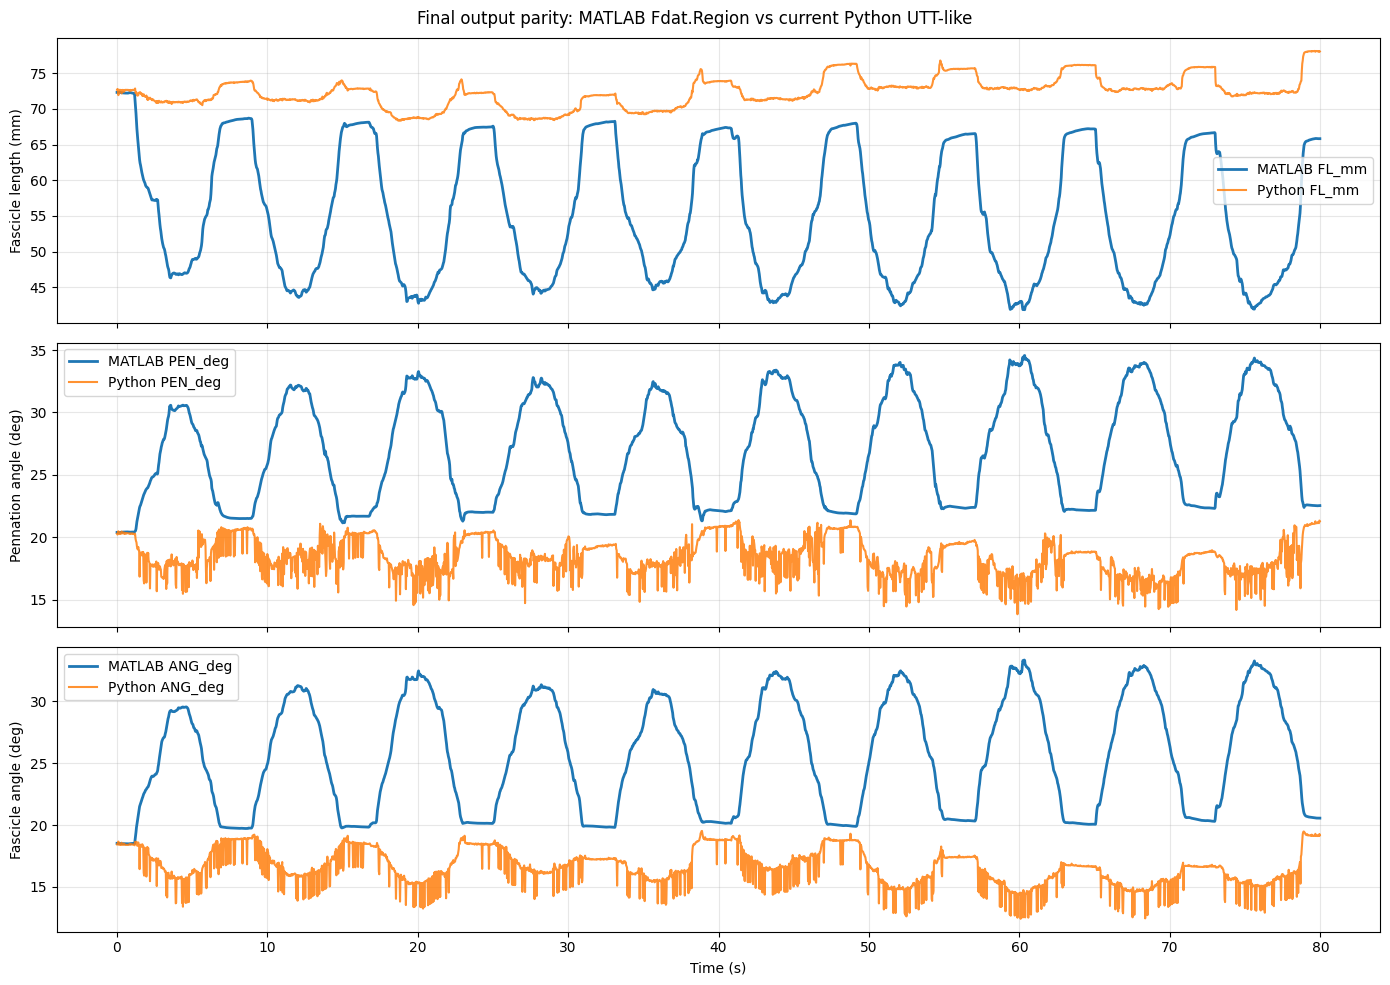

In [6]:
time_mat = mat_final["time_s"]
time_py = py_utt["time_s"]
n_final = min(len(time_mat), len(time_py), len(mat_final["length_mm"]), len(py_utt["utt_fascicle_length_px"]))
time = time_mat[:n_final]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (name, (ref, est, ylabel)) in zip(axes, final_pairs.items()):
    ref = np.asarray(ref[:n_final], dtype=float)
    est = np.asarray(est[:n_final], dtype=float)
    ax.plot(time, ref, linewidth=2.0, label=f"MATLAB {name}")
    ax.plot(time, est, linewidth=1.5, alpha=0.85, label=f"Python {name}")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Final output parity: MATLAB Fdat.Region vs current Python UTT-like")
plt.tight_layout()
plt.show()

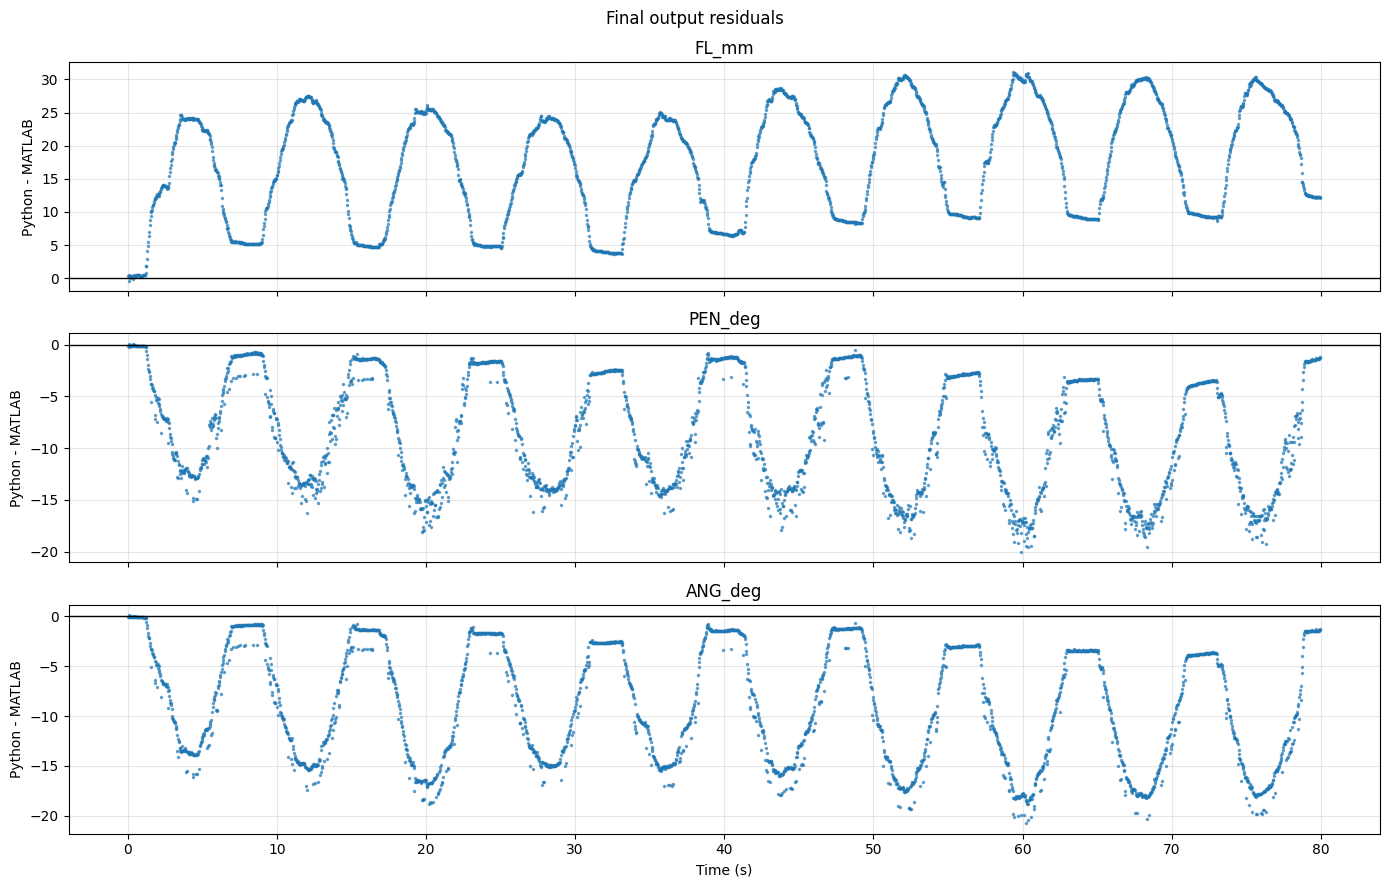

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, (name, (ref, est, ylabel)) in zip(axes, final_pairs.items()):
    ref = np.asarray(ref[:n_final], dtype=float)
    est = np.asarray(est[:n_final], dtype=float)
    diff = est - ref
    ax.plot(time, diff, ".", markersize=3, alpha=0.6)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_ylabel("Python - MATLAB")
    ax.grid(True, alpha=0.3)
    ax.set_title(name)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Final output residuals")
plt.tight_layout()
plt.show()

## 2. TimTrack Intermediate Parity Baseline

This is the most important next step.

MATLAB UltraTimTrack saves `Fdat.geofeatures`, which comes from TimTrack before the UltraTrack/Kalman fusion. If these intermediate measurements are different, final-output matching will be very hard.

Current finding: the Python TimTrack-like step is not yet equivalent to MATLAB TimTrack. This should be fixed before Kalman tuning.


In [8]:
timtrack_pairs = {
    "alpha_deg": (
        mat_geo["alpha_deg"],
        py_tim["fascicle_angle_deg"],
        "Fascicle angle alpha (deg)",
    ),
    "phi_vs_pen_deg": (
        mat_geo["phi_deg"],
        py_tim["pennation_angle_deg"],
        "MATLAB phi vs Python pennation (deg)",
    ),
    "faslen_px": (
        mat_geo["faslen_px"],
        py_tim["fascicle_length_px"],
        "Fascicle length (px)",
    ),
    "gamma_deep_apo_deg": (
        mat_geo["deep_apo_angle_deg"],
        py_tim["deep_apo_angle_deg"],
        "Deep aponeurosis angle gamma (deg)",
    ),
}

tim_rows = []
for name, (ref, est, _) in timtrack_pairs.items():
    tim_rows.append(mc.metric_row(name, *mc.align_by_index(ref, est)))

print(mc.format_metric_rows(tim_rows))

comparison                                n       bias        mae       rmse     corr
-------------------------------------------------------------------------------------
alpha_deg                              2666   -11.3908    11.6596    18.9680  -0.0963
phi_vs_pen_deg                         2666   -10.6825    10.9737    18.4155  -0.0837
faslen_px                              2666   146.0384   155.1435   183.6607   0.3736
gamma_deep_apo_deg                     2666    -0.4179     0.5972     0.8822   0.2069


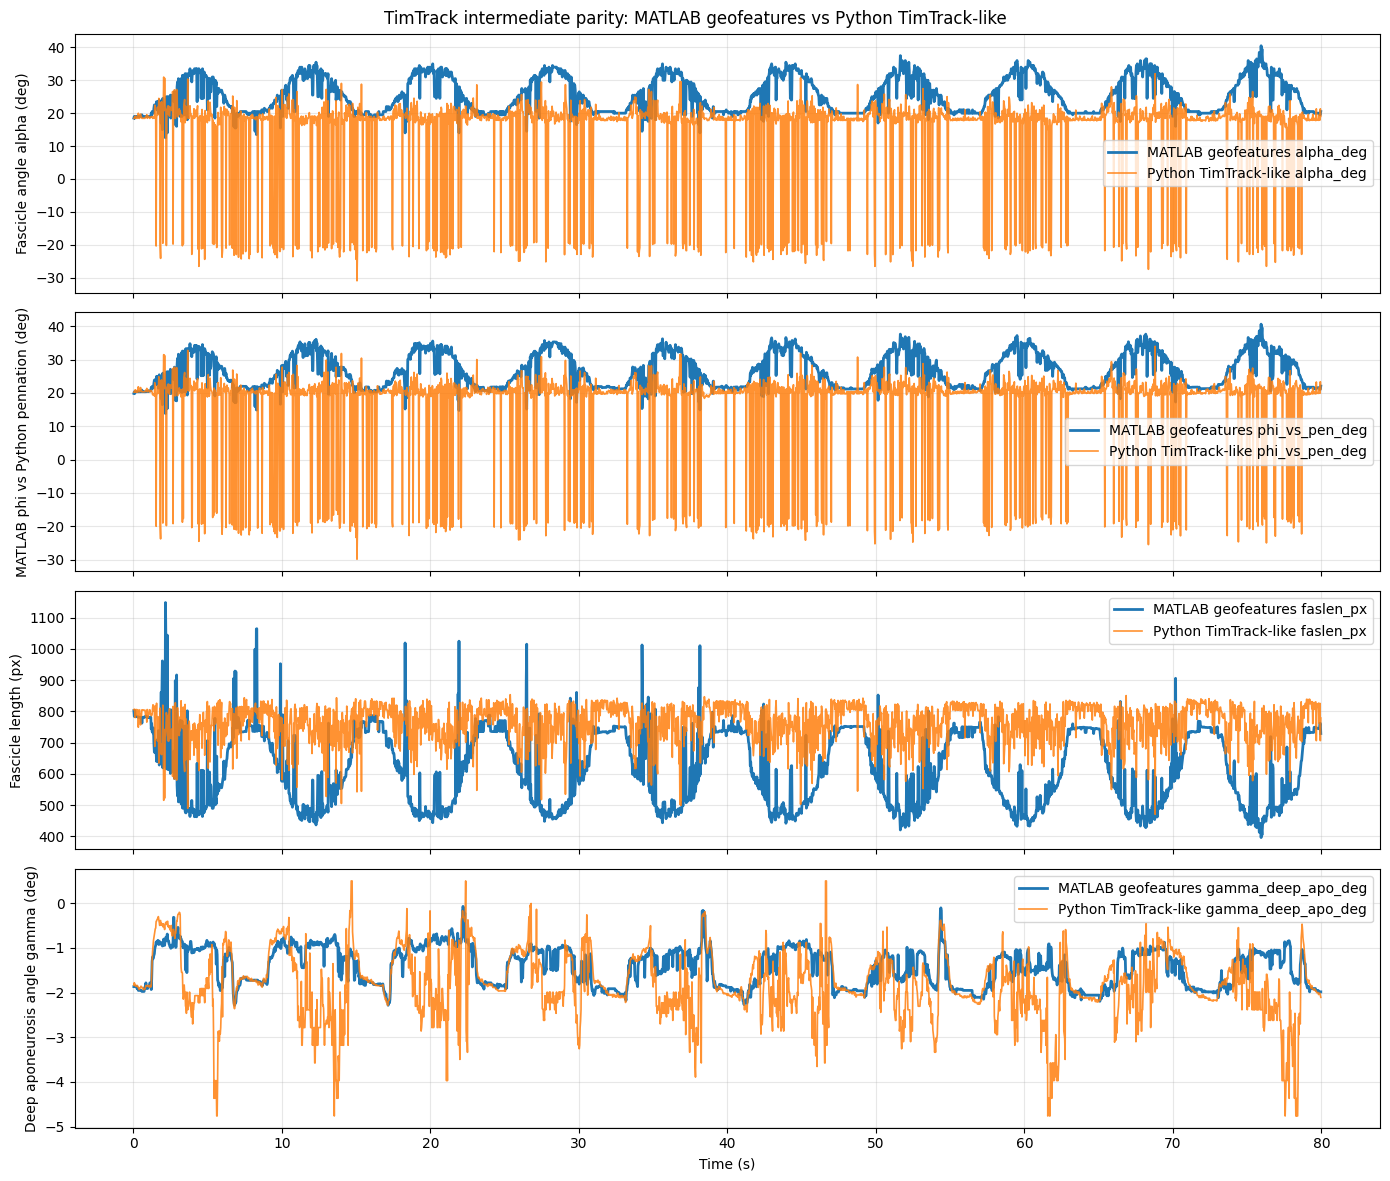

In [9]:
n_tim = min(len(mat_geo["alpha_deg"]), len(py_tim["frame"]))
time_tim = mat_final["time_s"][:n_tim]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, (name, (ref, est, ylabel)) in zip(axes, timtrack_pairs.items()):
    ref = np.asarray(ref[:n_tim], dtype=float)
    est = np.asarray(est[:n_tim], dtype=float)
    ax.plot(time_tim, ref, linewidth=2.0, label=f"MATLAB geofeatures {name}")
    ax.plot(time_tim, est, linewidth=1.2, alpha=0.85, label=f"Python TimTrack-like {name}")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("TimTrack intermediate parity: MATLAB geofeatures vs Python TimTrack-like")
plt.tight_layout()
plt.show()

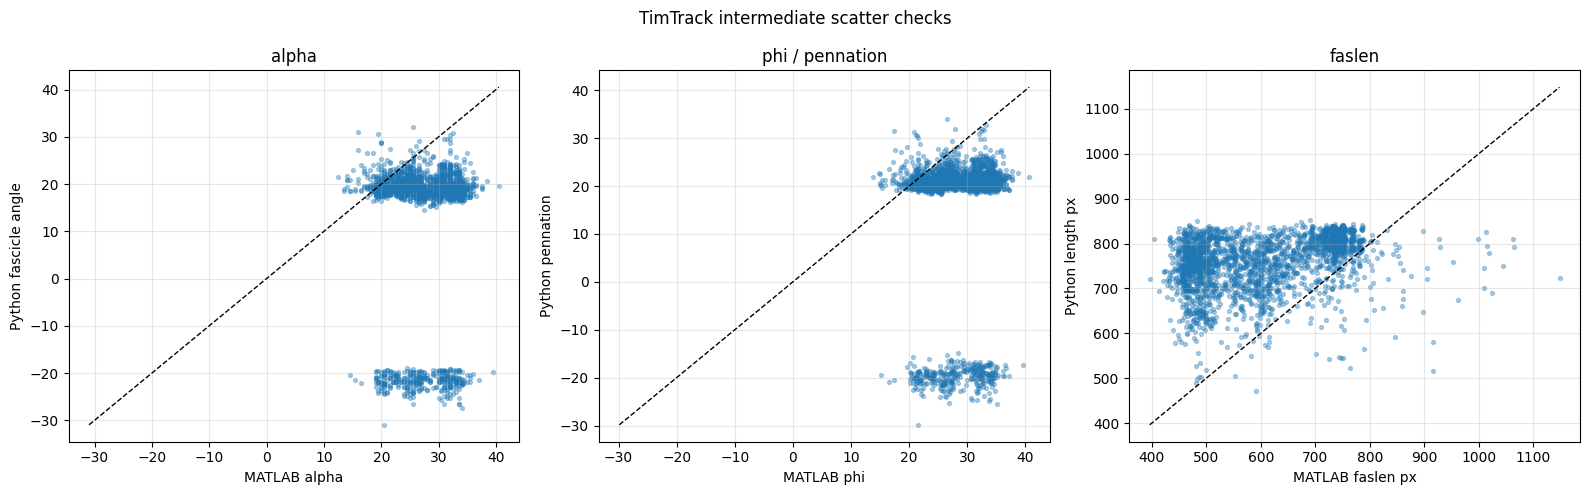

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_specs = [
    (mat_geo["alpha_deg"], py_tim["fascicle_angle_deg"], "alpha", "MATLAB alpha", "Python fascicle angle"),
    (mat_geo["phi_deg"], py_tim["pennation_angle_deg"], "phi / pennation", "MATLAB phi", "Python pennation"),
    (mat_geo["faslen_px"], py_tim["fascicle_length_px"], "faslen", "MATLAB faslen px", "Python length px"),
]

for ax, (ref, est, title, xlabel, ylabel) in zip(axes, scatter_specs):
    ref, est = mc.valid_pair(ref, est)
    ax.scatter(ref, est, s=8, alpha=0.35)
    mn = min(np.nanmin(ref), np.nanmin(est))
    mx = max(np.nanmax(ref), np.nanmax(est))
    ax.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig.suptitle("TimTrack intermediate scatter checks")
plt.tight_layout()
plt.show()

## 3. Applied `segment_from_state()` Replacement

The function from your attachment has now been applied in:

```text
ultrasound_tracker/ultratimtrack_kalman.py
```

This section keeps the old branch beside the patched branch so we can see what changed.

Why it matters: the state stores a normalized fascicle angle, for example around `18 deg`. That angle does not encode whether the segment points up-right or down-left. For this dataset, the MATLAB-style fascicle goes from the superficial/right attachment down-left to the deep attachment.


In [11]:
def segment_from_state_patched_reference(state: np.ndarray) -> np.ndarray:
    """
    Reference copy of the patched segment_from_state() logic.

    The real implementation now lives in:
        ultrasound_tracker/ultratimtrack_kalman.py
    """
    state = np.asarray(state, dtype=np.float32)

    if state.shape != (4,):
        raise ValueError(f"Expected shape (4,), got {state.shape}")

    x_sup = float(state[0])
    y_sup = float(state[1])
    angle_deg = float(state[2])
    length_px = float(state[3])

    theta = np.deg2rad(angle_deg)

    x_deep = x_sup - length_px * np.cos(theta)
    y_deep = y_sup + length_px * np.sin(theta)

    return np.array(
        [x_sup, y_sup, x_deep, y_deep],
        dtype=np.float32,
    )

In [12]:
def segment_from_state_previous_formula(state: np.ndarray) -> np.ndarray:
    """The old implementation kept here only for visual comparison."""
    state = np.asarray(state, dtype=np.float32)
    x_sup, y_sup, angle_deg, length_px = [float(v) for v in state]
    theta = np.deg2rad(angle_deg)
    x_deep = x_sup + length_px * np.cos(theta)
    y_deep = y_sup - length_px * np.sin(theta)
    return np.array([x_sup, y_sup, x_deep, y_deep], dtype=np.float32)

example_idx = 0
example_state = py_utt["utt_states"][example_idx]
print("Example state:", example_state)
print("Previous formula segment:", segment_from_state_previous_formula(example_state))
print("Patched reference segment:", segment_from_state_patched_reference(example_state))
print("Current utt.segment_from_state segment:", utt.segment_from_state(example_state))
print("Saved regenerated Python segment:", py_utt["utt_segments"][example_idx])
print("TimTrack segment:", py_tim["fascicle_segments"][example_idx])

Example state: [715.6046    52.798447  18.434952 805.5336  ]
Previous formula segment: [ 715.6046     52.798447 1479.8009   -201.9337  ]
Patched reference segment: [715.6046    52.798447 -48.591675 307.53058 ]
Current utt.segment_from_state segment: [715.6046    52.798447 -48.591675 307.53058 ]
Saved regenerated Python segment: [715.6046    52.798447 -48.591675 307.53058 ]
TimTrack segment: [715.6046    52.798447 -48.591675 307.53058 ]


In [13]:
states = py_utt["utt_states"].astype(np.float32)
previous_segments_from_state = np.vstack([segment_from_state_previous_formula(s) for s in states])
patched_segments_from_state = np.vstack([utt.segment_from_state(s) for s in states])

previous_deep = previous_segments_from_state[:, 2:4]
patched_deep = patched_segments_from_state[:, 2:4]
timtrack_deep = py_tim["deep_attachments"][:len(states)]

# Inside-frame checks for deep endpoints.
def inside_frame(points):
    x = points[:, 0]
    y = points[:, 1]
    return (x >= 0) & (x < image_width_px) & (y >= 0) & (y < image_height_px)

inside_previous = inside_frame(previous_deep)
inside_patched = inside_frame(patched_deep)
inside_timtrack = inside_frame(timtrack_deep)

print("Deep endpoint inside image:")
print("  previous formula:", f"{100*np.mean(inside_previous):.1f}%")
print("  patched formula :", f"{100*np.mean(inside_patched):.1f}%")
print("  TimTrack segment:", f"{100*np.mean(inside_timtrack):.1f}%")

print("Previous x_deep range:", np.nanmin(previous_deep[:, 0]), np.nanmax(previous_deep[:, 0]))
print("Patched x_deep range:", np.nanmin(patched_deep[:, 0]), np.nanmax(patched_deep[:, 0]))
print("Frame width:", image_width_px)
print("Previous y_deep range:", np.nanmin(previous_deep[:, 1]), np.nanmax(previous_deep[:, 1]))
print("Patched y_deep range:", np.nanmin(patched_deep[:, 1]), np.nanmax(patched_deep[:, 1]))
print("Frame height:", image_height_px)

Deep endpoint inside image:
  previous formula: 0.0%
  patched formula : 60.8%
  TimTrack segment: 31.6%
Previous x_deep range: 1458.4169 1677.6711
Patched x_deep range: -79.00713 119.57335
Frame width: 706
Previous y_deep range: -274.3199 -93.27603
Patched y_deep range: 241.16772 312.5825
Frame height: 562


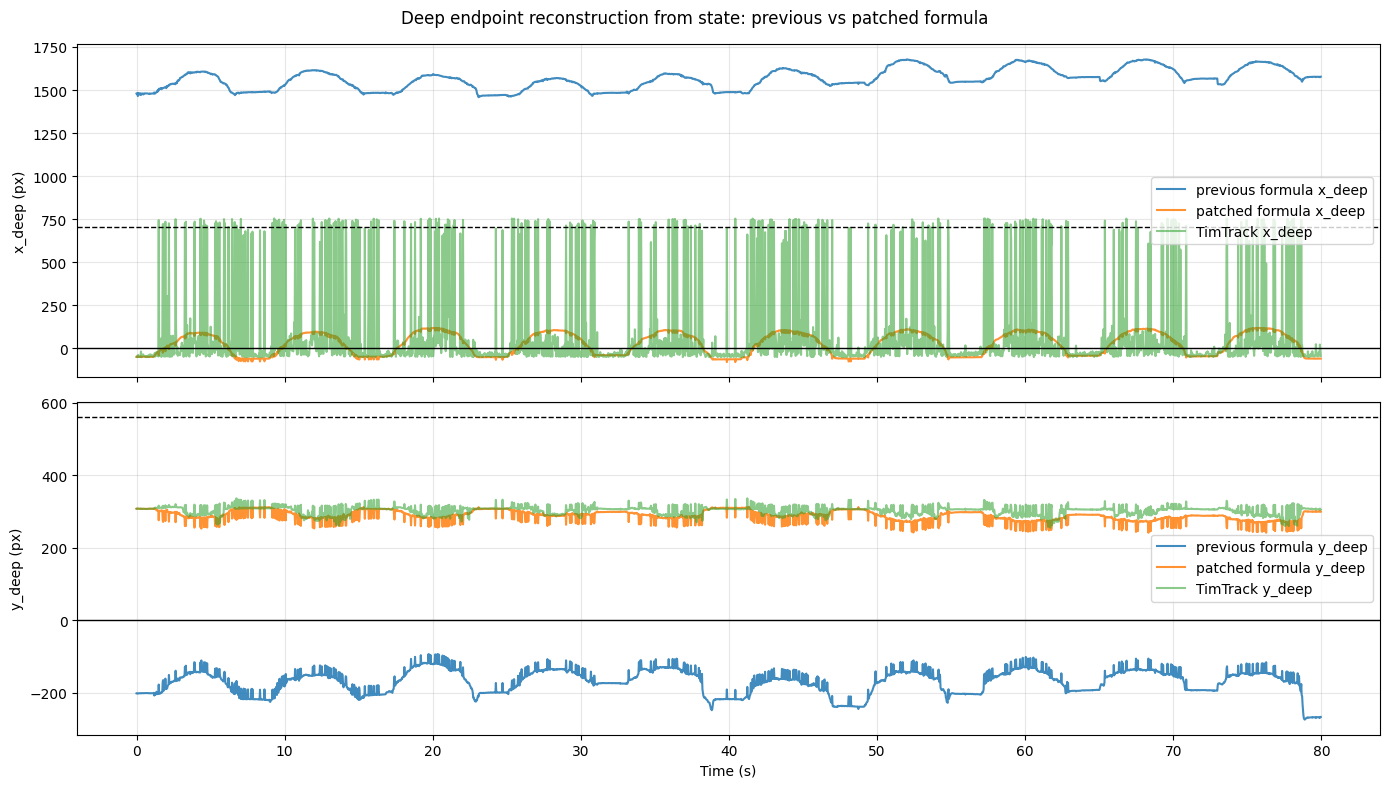

In [14]:
time_utt = py_utt["time_s"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(time_utt, previous_deep[:, 0], label="previous formula x_deep", alpha=0.85)
axes[0].plot(time_utt, patched_deep[:, 0], label="patched formula x_deep", alpha=0.85)
axes[0].plot(time_utt[:len(timtrack_deep)], timtrack_deep[:, 0], label="TimTrack x_deep", alpha=0.55)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axhline(image_width_px - 1, color="black", linewidth=1, linestyle="--")
axes[0].set_ylabel("x_deep (px)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

axes[1].plot(time_utt, previous_deep[:, 1], label="previous formula y_deep", alpha=0.85)
axes[1].plot(time_utt, patched_deep[:, 1], label="patched formula y_deep", alpha=0.85)
axes[1].plot(time_utt[:len(timtrack_deep)], timtrack_deep[:, 1], label="TimTrack y_deep", alpha=0.55)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].axhline(image_height_px - 1, color="black", linewidth=1, linestyle="--")
axes[1].set_ylabel("y_deep (px)")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

fig.suptitle("Deep endpoint reconstruction from state: previous vs patched formula")
plt.tight_layout()
plt.show()

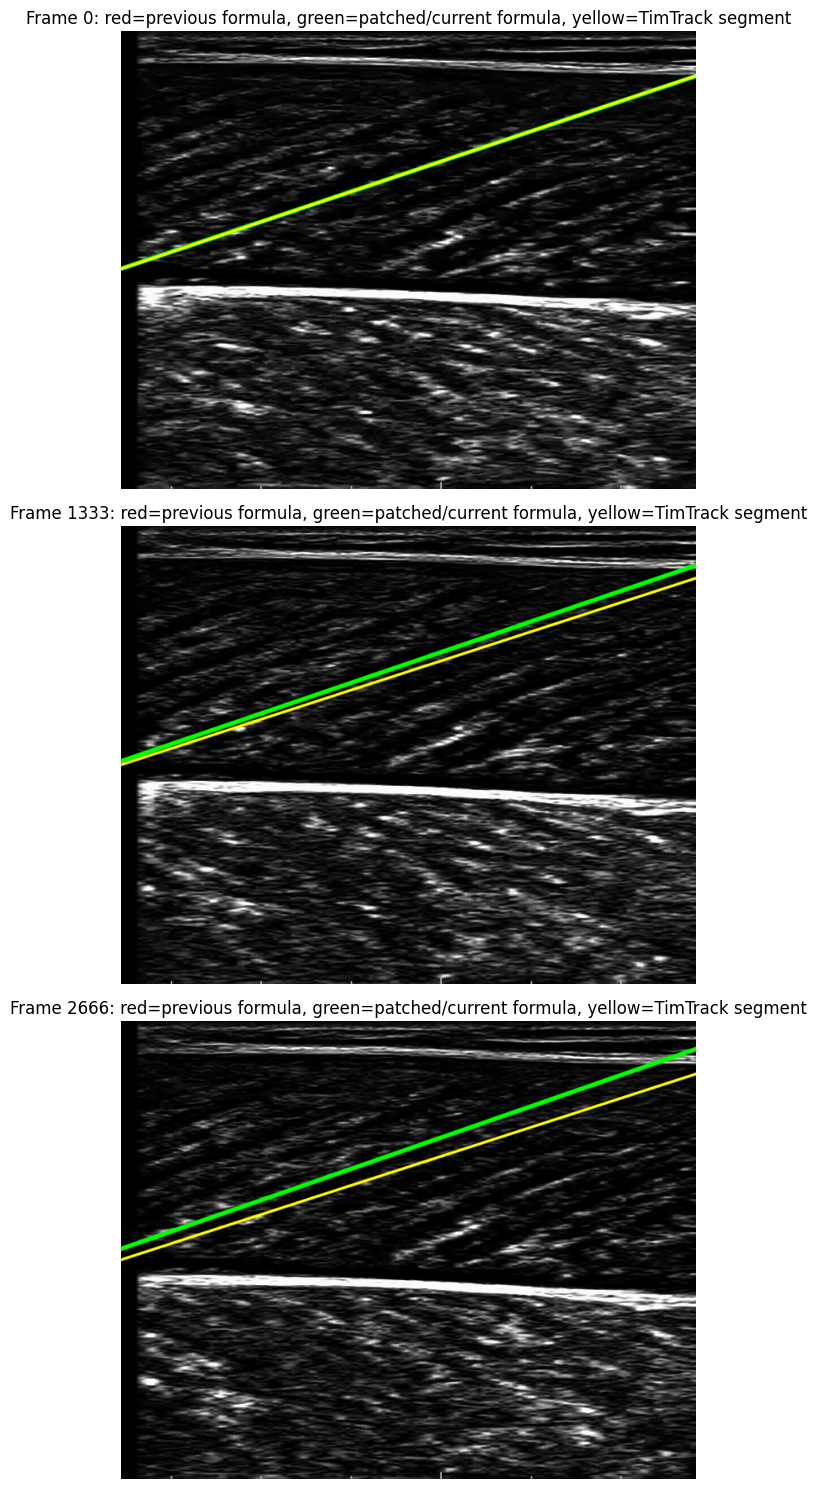

In [15]:
def draw_segment(img_bgr, segment, color, thickness=3):
    if segment is None or not np.all(np.isfinite(segment)):
        return img_bgr
    x1, y1, x2, y2 = np.asarray(segment).astype(int)
    cv2.line(img_bgr, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    cv2.circle(img_bgr, (x1, y1), 5, color, -1)
    cv2.circle(img_bgr, (x2, y2), 5, color, -1)
    return img_bgr

valid_indices = np.where(py_utt["success"])[0]
selected_indices = [valid_indices[0], valid_indices[len(valid_indices)//2], valid_indices[-1]]

fig, axes = plt.subplots(len(selected_indices), 1, figsize=(14, 5 * len(selected_indices)))
if len(selected_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, selected_indices):
    frame_idx = int(py_utt["frame"][idx])
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        ax.set_title(f"Could not read frame {frame_idx}")
        ax.axis("off")
        continue

    if frame.ndim == 2:
        vis = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
    else:
        vis = frame.copy()

    # BGR colors: red=previous, green=patched/current, yellow=TimTrack.
    draw_segment(vis, previous_segments_from_state[idx], (0, 0, 255), thickness=3)
    draw_segment(vis, patched_segments_from_state[idx], (0, 255, 0), thickness=3)
    draw_segment(vis, py_tim["fascicle_segments"][idx], (0, 255, 255), thickness=2)

    ax.imshow(vis[..., ::-1])
    ax.set_title(
        f"Frame {frame_idx}: red=previous formula, green=patched/current formula, yellow=TimTrack segment"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. What This Means For The Next Coding Step

The patched `segment_from_state()` fixes the reconstruction branch for this dataset: it converts the normalized state angle back into the down-left segment that MATLAB-style geometry expects.

But this is only one bug. The bigger parity blocker is still TimTrack intermediate mismatch.

Recommended next code step:

1. Keep this notebook as the baseline trace.
2. Keep the new geometry regression test.
3. Start porting MATLAB TimTrack's `dohough.m` + `weightedMedian.m`, because the current Python TimTrack-like `alpha` is the main mismatch.
4. Recheck MATLAB `geofeatures` alpha/phi/faslen parity after each TimTrack change.


In [16]:
print("Next implementation checklist")
print("[x] Replace segment_from_state() with the down-left branch")
print("[x] Add a geometry regression test for state <-> segment reconstruction")
print("[x] Rerun notebook 16 and this notebook")
print("[ ] Port MATLAB dohough.m and weightedMedian.m")
print("[ ] Recheck MATLAB geofeatures alpha/phi/faslen parity")

Next implementation checklist
[x] Replace segment_from_state() with the down-left branch
[x] Add a geometry regression test for state <-> segment reconstruction
[x] Rerun notebook 16 and this notebook
[ ] Port MATLAB dohough.m and weightedMedian.m
[ ] Recheck MATLAB geofeatures alpha/phi/faslen parity
